# Project: Predicting Titanic Survival Using Logistic Regression

## Purpose

This data analysis report aims to:

- Perform a **logistic regression analysis** of Titanic passenger survival using attributes such as gender and cabin class.  
- Leverage the resulting model to **predict** whether passengers with unknown outcomes survived the sinking event based on their attributes.

## Intro

RMS Titanic was an Olympic-class ocean liner that sank after striking an iceberg on its maiden voyage in April 1912. She was the second of three superliners in her class, along with her sister ships Olympic and Britannic, providing transatlantic travel for White Star Line passengers.

Built by the Harland and Wolff shipyard in Belfast, Northern Ireland, Titanic was the largest passenger vessel of its time; so large that it was compared to a modern aircraft carrier and nicknamed the “unsinkable” giant liner. On her maiden voyage, she departed from Southampton, England, called at Cherbourg-Octeville, France and Queenstown, Ireland, then set out across the Atlantic for New York City. Due to human error, she struck an iceberg at 11:40 PM ship’s time on April 14, 1912, and 2 hours and 40 minutes later, at 2:20 AM on April 15, she broke in two and sank in the Atlantic Ocean. More than 1,500 people died, making it the deadliest maritime disaster of the 20th century and one of the most famous shipwrecks in history.

The dataset includes two tables: `titanic_train.csv` and `titanic_test.csv`.

`titanic_train.csv` records the survival outcomes and related information for over 800 Titanic passengers, including passenger class, sex, age, number of siblings/spouses aboard, number of parents/children aboard, and more.

`titanic_test.csv` contains only passenger information for those not included in `titanic_train.csv` and can be used to **predict** whether those passengers survived.

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
original_data = pd.read_csv('titanic_train.csv')
original_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Clean

In [4]:
cleaned_data = original_data.copy()

In [5]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


There is missing data in `Age`, `Cabin` and `Embarked`

`Cabin` has too much missing information and serves no substantial purpose for the current data analysis, therefore it is directly removed

`Embarked` also serves no substantial purpose for the current data analysis.

`Age` is an important variables for logistic regression, so I'd better fill `NaN` with average age

### Deal with Missing Data

In [8]:
cleaned_data = cleaned_data.drop('Cabin', axis=1)
cleaned_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [10]:
average_age = cleaned_data['Age'].mean()
cleaned_data['Age'] = cleaned_data['Age'].fillna(average_age)
cleaned_data['Age'].isna().sum()

np.int64(0)

### Deal with Duplicated Data (no duplicated ones)

In [11]:
cleaned_data.duplicated().sum()

np.int64(0)

### Deal with Incorrect Data

In [12]:
cleaned_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
cleaned_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
cleaned_data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [15]:
cleaned_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [16]:
cleaned_data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

### Deal with Types of Data

In [20]:
cleaned_data = cleaned_data.astype({
    'PassengerId': str,
    'Survived': 'category',
    'Pclass': 'category',
    'Sex': 'category',
    'Age': int,
})
cleaned_data.dtypes

PassengerId      object
Survived       category
Pclass         category
Name             object
Sex            category
Age               int64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
dtype: object

At last, I'd like to drop `Ticket`, `Embarked`, `Name` to better perform data analysis in the next stage.

In [19]:
cleaned_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S


In [22]:
streamlined_data = cleaned_data.copy()
streamlined_data = streamlined_data.drop(['Name', 'Ticket', 'Embarked'], axis=1)

streamlined_data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,male,22,1,0,7.2500
1,2,1,1,female,38,1,0,71.2833
2,3,1,3,female,26,0,0,7.9250
3,4,1,1,female,35,1,0,53.1000
4,5,0,3,male,35,0,0,8.0500


## Explore

In [25]:
# combine the data of 'SibSp' and 'Parch' to figure out how the number of family members affects the survival rate
streamlined_data['FamilyNum'] = streamlined_data['SibSp'] + streamlined_data['Parch']
streamlined_data.drop(['SibSp', 'Parch'], axis=1, inplace=True)

streamlined_data.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,FamilyNum
0,1,0,3,male,22,7.2500,1
1,2,1,1,female,38,71.2833,1
2,3,1,3,female,26,7.9250,0
3,4,1,1,female,35,53.1000,1
4,5,0,3,male,35,8.0500,0


In [27]:
sns.set_palette('Set2')

plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True

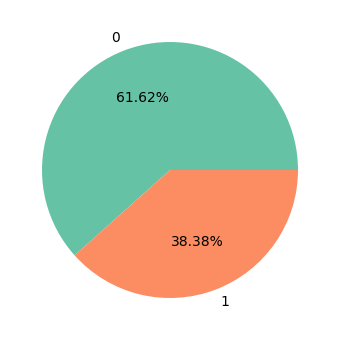

In [31]:
survival_count = streamlined_data['Survived'].value_counts()
survival_label = survival_count.index

plt.pie(survival_count, labels=survival_label, autopct='%.2f%%')
plt.show()

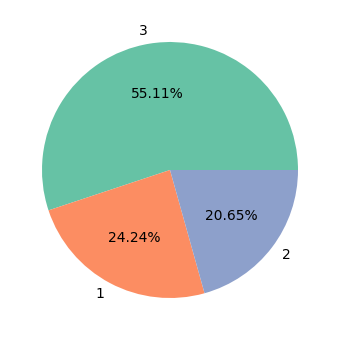

In [32]:
Pclass_count = streamlined_data['Pclass'].value_counts()
Pclass_label = Pclass_count.index

plt.pie(Pclass_count, labels=Pclass_label, autopct='%.2f%%')
plt.show()

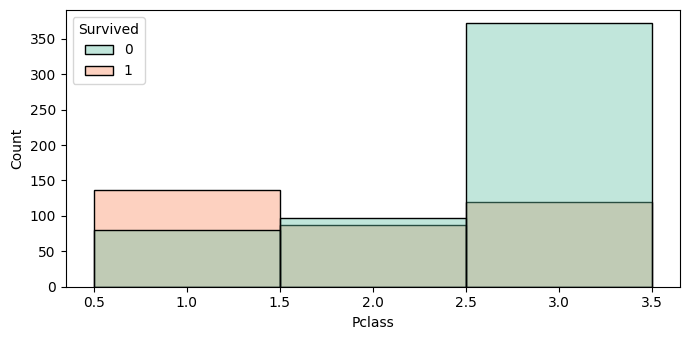

In [34]:
sns.histplot(streamlined_data, x='Pclass', hue='Survived', alpha=0.4)
plt.show()

As shown in the above figure, the higher the Pclass (i.e., the passenger’s cabin class), the higher the survival rate

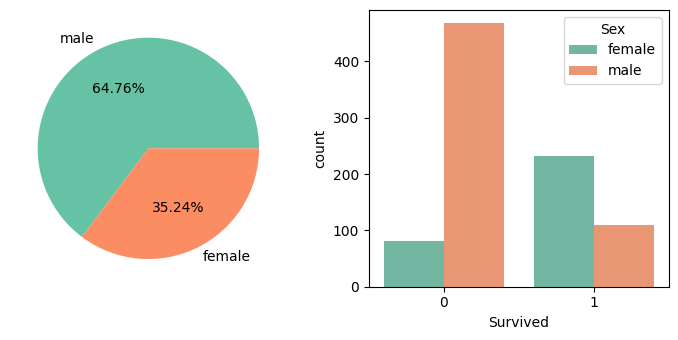

In [36]:
figure, axes = plt.subplots(1, 2)

sex_count = streamlined_data['Sex'].value_counts()
sex_label = sex_count.index

axes[0].pie(sex_count, labels=sex_label, autopct='%.2f%%')
sns.countplot(streamlined_data, x='Survived', hue='Sex', ax=axes[1])
plt.show()

As shown in the figure above, the proportion of female survivors is higher, at least twice that of males

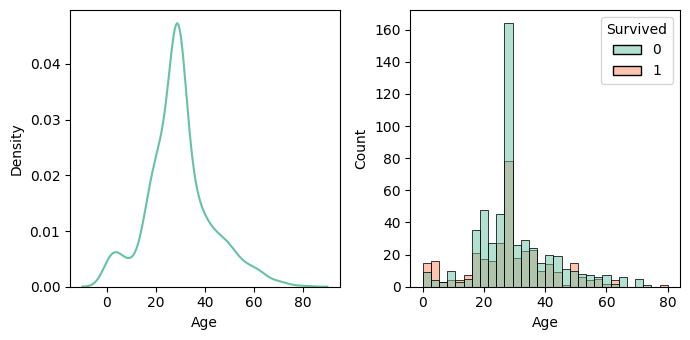

In [47]:
figure, axes = plt.subplots(1, 2)

sns.kdeplot(streamlined_data['Age'], ax=axes[0])
sns.histplot(streamlined_data, x='Age', hue='Survived', ax=axes[1])

plt.show()

From the passenger age histogram, only the infant group shows a higher survival rate; in the vast majority of other age groups, fatalities exceed survivors

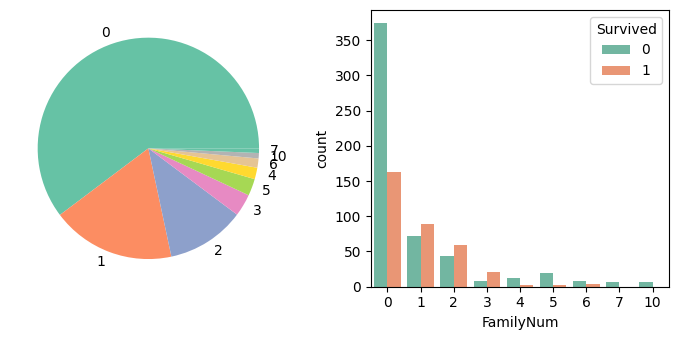

In [52]:
figure, axes = plt.subplots(1, 2)

familyNum_count = streamlined_data['FamilyNum'].value_counts()
familyNum_label = familyNum_count.index

axes[0].pie(familyNum_count, labels=familyNum_label)
sns.countplot(streamlined_data, hue='Survived', x='FamilyNum', ax=axes[1])
plt.show()

From the bar chart comparing survival rates and number of family members among passengers, more single passengers died than survived. 

Among passengers traveling with family members, those with 1–3 family members had more survivors than fatalities, but when more than 3 family members traveled together, fatalities outnumbered survivors.

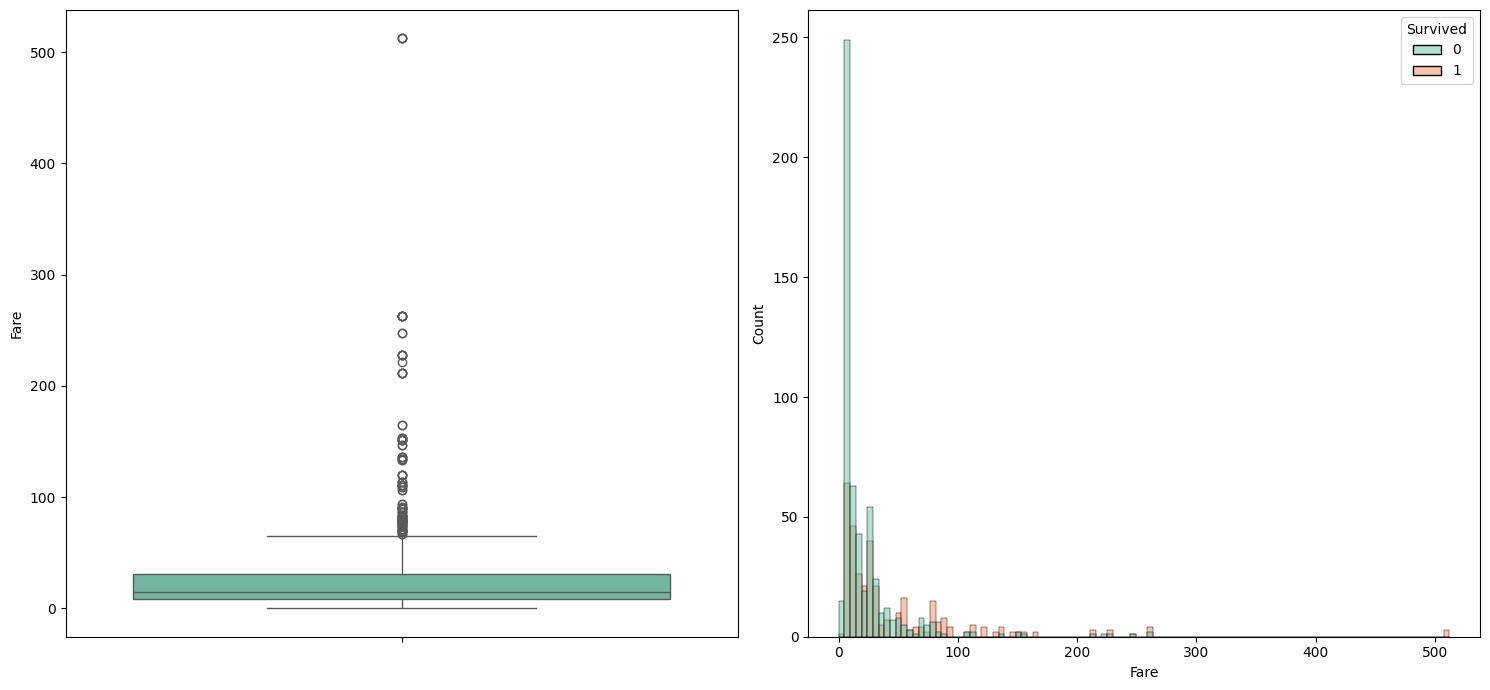

In [62]:
figure, axes = plt.subplots(1, 2, figsize=[15, 7])

sns.boxplot(streamlined_data, y='Fare', ax=axes[0])
sns.histplot(streamlined_data, x='Fare', hue='Survived', ax=axes[1])
plt.show()

Overall, there is a positive correlation between survival rate and ticket price.

## Logistic Regression

In [68]:
analysed_data = streamlined_data.copy()
analysed_data.drop('PassengerId', axis=1, inplace=True)

In [69]:
analysed_data = pd.get_dummies(analysed_data,
                               columns=['Pclass', 'Sex'],
                               dtype=int,
                               drop_first=True)
analysed_data.head()

,Survived,Age,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,0,22,7.2500,1,0,1,1
1,1,38,71.2833,1,0,0,0
2,1,26,7.9250,0,0,1,0
3,1,35,53.1000,1,0,0,0
4,0,35,8.0500,0,0,1,1


In [70]:
analysed_data.corr().abs() > 0.8

,Survived,Age,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
Survived,True,False,False,False,False,False,False
Age,False,True,False,False,False,False,False
Fare,False,False,True,False,False,False,False
FamilyNum,False,False,False,True,False,False,False
Pclass_2,False,False,False,False,True,False,False
Pclass_3,False,False,False,False,False,True,False
Sex_male,False,False,False,False,False,False,True


In [75]:
y = analysed_data['Survived']
X = analysed_data.drop('Survived', axis=1)

X = sm.add_constant(X)
X.head()

,const,Age,Fare,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,1.0,22,7.2500,1,0,1,1
1,1.0,38,71.2833,1,0,0,0
2,1.0,26,7.9250,0,0,1,0
3,1.0,35,53.1000,1,0,0,0
4,1.0,35,8.0500,0,0,1,1


In [76]:
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.443602
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      884
Method:                           MLE   Df Model:                            6
Date:                Fri, 30 May 2025   Pseudo R-squ.:                  0.3338
Time:                        13:31:38   Log-Likelihood:                -395.25
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.874e-82
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.7985      0.443      8.571      0.000       2.930       4.667
Age           -0.0387      0.008     -4.954      0.000      -0.054      -0.023
Fare           0.0032      0.002      1.316      0.188      -0.002       0.008
FamilyNum     -0.2421      0.068     -3.586      0.000      -0.374      -0.110
Pclass_2      -0.9966      0.293     -3.405      0.001      -1.570      -0.423
Pclass_3      -2.1338      0.289     -7.374      0.000      -2.701      -1.567
Sex_male      -2.7757      0.199    -13.983      0.000      -3.165      -2.387
==============================================================================
"""

The p-value for Fare is greater than 0.05, so it should be removed from the data and the model refit

In [77]:
X.drop('Fare', axis=1, inplace=True)

In [78]:
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.444686
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      885
Method:                           MLE   Df Model:                            5
Date:                Fri, 30 May 2025   Pseudo R-squ.:                  0.3322
Time:                        13:31:48   Log-Likelihood:                -396.22
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 5.211e-83
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0512      0.403     10.058      0.000       3.262       4.841
Age           -0.0394      0.008     -5.055      0.000      -0.055      -0.024
FamilyNum     -0.2176      0.064     -3.373      0.001      -0.344      -0.091
Pclass_2      -1.1766      0.261     -4.509      0.000      -1.688      -0.665
Pclass_3      -2.3480      0.243     -9.677      0.000      -2.824      -1.872
Sex_male      -2.7851      0.198    -14.072      0.000      -3.173      -2.397
==============================================================================
"""

The logistic regression model predicts that the following factors, when increased or present, decrease the probability of survival: age, number of accompanying family members, not being in first class, and being male.

In [81]:
coef_dict = {
    "Age": -0.0394,
    "FamilyNum": -0.2176,
    "Pclass_2": -1.1766,
    "Pclass_3": -2.3480,
    "Sex_male": -2.7851
}

for name, coef in coef_dict.items():
    OR = np.exp(coef)
    percent = (1-OR)*100 if OR < 1 else (OR-1)*100
    print(f"{name}: OR={OR:.3f}，Survival rate decreases by approximately {percent:.1f}%")

Age: OR=0.961，Survival rate decreases by approximately 3.9%
FamilyNum: OR=0.804，Survival rate decreases by approximately 19.6%
Pclass_2: OR=0.308，Survival rate decreases by approximately 69.2%
Pclass_3: OR=0.096，Survival rate decreases by approximately 90.4%
Sex_male: OR=0.062，Survival rate decreases by approximately 93.8%


## Test

In [91]:
test_data = pd.read_csv('titanic_test.csv')

In [92]:
test_data.drop(['PassengerId', 'Name', 'Ticket', 'Fare', 'Cabin', 'Embarked'], axis=1, inplace=True)
test_data.head()

,Pclass,Sex,Age,SibSp,Parch
0,3,male,34.5,0,0
1,3,female,47.0,1,0
2,2,male,62.0,0,0
3,3,male,27.0,0,0
4,3,female,22.0,1,1


In [93]:
test_data['Pclass'] = pd.Categorical(test_data['Pclass'], categories=[1, 2, 3])
test_data['Sex'] = pd.Categorical(test_data['Sex'], categories=['female', 'male'])

In [94]:
test_data['FamilyNum'] = test_data['SibSp'] + test_data['Parch']
test_data.drop(['SibSp', 'Parch'], axis=1, inplace=True)
test_data.head()

,Pclass,Sex,Age,FamilyNum
0,3,male,34.5,0
1,3,female,47.0,1
2,2,male,62.0,0
3,3,male,27.0,0
4,3,female,22.0,2


In [95]:
test_data = pd.get_dummies(test_data,
                           columns=['Pclass', 'Sex'],
                           dtype=int,
                           drop_first=True)
test_data.head()

,Age,FamilyNum,Pclass_2,Pclass_3,Sex_male
0,34.5,0,0,1,1
1,47.0,1,0,1,0
2,62.0,0,1,0,1
3,27.0,0,0,1,1
4,22.0,2,0,1,0


In [96]:
test_data = sm.add_constant(test_data)

In [99]:
predicted_data = model.predict(test_data)
(predicted_data > 0.7).sum()

np.int64(86)